In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\donov\Downloads\Data.RawProject\steam_games_dataset.csv")

df

,appid,name,developer,publisher,score_rank,positive,negative,userscore,owners,average_forever,average_2weeks,median_forever,median_2weeks,price,initialprice,discount,ccu
0,730,Counter-Strike: Global Offensive,Valve,Valve,NaN,7642084,1173003,0,"100,000,000 .. 200,000,000",33852,708,6645,301,0,0,0,1013936
1,1172470,Apex Legends,Respawn,Electronic Arts,NaN,668053,326926,0,"100,000,000 .. 200,000,000",10506,496,935,246,0,0,0,124262
2,578080,PUBG: BATTLEGROUNDS,PUBG Corporation,"KRAFTON, Inc.",NaN,1520457,1037487,0,"100,000,000 .. 200,000,000",23165,717,5622,261,0,0,0,314682
3,1623730,Palworld,Pocketpair,Pocketpair,NaN,358266,22443,0,"50,000,000 .. 100,000,000",3854,835,2213,257,2999,2999,0,18028
4,440,Team Fortress 2,Valve,Valve,NaN,1044264,117208,0,"50,000,000 .. 100,000,000",21244,736,4262,102,0,0,0,43819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,444720,Inexistence,Jonathan BRASSAUD,Jonathan BRASSAUD,NaN,242,126,0,"50,000 .. 100,000",279,0,313,0,299,299,0,0
9996,649600,Swords and Sandals 2 Redux,Whiskeybarrel Studios,eGames.com,NaN,429,117,0,"50,000 .. 100,000",333,0,432,0,999,999,0,4
9997,1122120,STATIONflow,DMM GAMES,DMM GAMES,NaN,414,66,0,"50,000 .. 100,000",984,0,984,0,1799,1799,0,6
9998,424640,Karaski: What Goes Up...,Unbound Creations,Unbound Creations,NaN,51,8,0,"50,000 .. 100,000",0,0,0,0,1199,1199,0,0


In [ ]:
## Data Cleaning and Preprocessing ##

In [2]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
appid                 0
name                  0
developer            33
publisher            54
score_rank         9995
positive              0
negative              0
userscore             0
owners                0
average_forever       0
average_2weeks        0
median_forever        0
median_2weeks         0
price                 0
initialprice          0
discount              0
ccu                   0
dtype: int64


In [3]:
# Missing Values after handling
if 'score_rank' in df.columns:
    df = df.drop('score_rank', axis=1)

# Impute missing 'developer' values with the mode
mode_developer = df['developer'].mode()[0]
df['developer'] = df['developer'].fillna(mode_developer)

# Impute missing 'publisher' values with the mode
mode_publisher = df['publisher'].mode()[0]
df['publisher'] = df['publisher'].fillna(mode_publisher)

print("Missing Values after handling:")
print(df.isnull().sum())

Missing Values after handling:
appid              0
name               0
developer          0
publisher          0
positive           0
negative           0
userscore          0
owners             0
average_forever    0
average_2weeks     0
median_forever     0
median_2weeks      0
price              0
initialprice       0
discount           0
ccu                0
dtype: int64


In [4]:
# Convert price from cents to dollars
df['price_usd'] = df['price'] / 100
df['initialprice_usd'] = df['initialprice'] / 100

In [7]:
display(df[['price_usd', 'initialprice_usd']].head(20))

,price_usd,initialprice_usd
0,0.00,0.00
1,0.00,0.00
2,0.00,0.00
3,29.99,29.99
4,0.00,0.00
5,38.49,69.99
6,59.99,59.99
7,59.99,59.99
8,0.00,0.00
9,9.99,9.99


In [8]:
# Calculate review metrics
df['total_reviews'] = df['positive'] + df['negative']
df['positive_ratio'] = df['positive'] / df['total_reviews'] * 100

In [9]:
display(df[['total_reviews', 'positive_ratio']].head(20))

,total_reviews,positive_ratio
0,8815087,86.693234
1,994979,67.142422
2,2557944,59.440590
3,380709,94.104946
4,1161472,89.908668
5,714114,58.757285
6,286878,68.599893
7,1150098,96.663067
8,1990556,87.411758
9,963983,97.535019


In [17]:
# Convert playtime from minutes to hours
df['avg_hours_forever'] = df['average_forever'] / 60
df['avg_hours_2weeks'] = df['average_2weeks'] / 60

display(df[['average_forever', 'avg_hours_forever', 'average_2weeks', 'avg_hours_2weeks']].head(20))

,average_forever,avg_hours_forever,average_2weeks,avg_hours_2weeks
0,33852,564.200000,708,11.800000
1,10506,175.100000,496,8.266667
2,23165,386.083333,717,11.950000
3,3854,64.233333,835,13.916667
4,21244,354.066667,736,12.266667
5,5397,89.950000,639,10.650000
6,10588,176.466667,18,0.300000
7,3268,54.466667,524,8.733333
8,13153,219.216667,699,11.650000
9,2479,41.316667,352,5.866667


In [ ]:
## Basic Statistics ##

In [26]:
# Summary statistics for numeric columns
numeric_cols = ['positive', 'negative', 'price_usd', 'ccu', 'avg_hours_forever']
print(df[numeric_cols].describe())

           positive      negative     price_usd           ccu  \
count  1.000000e+04  1.000000e+04  10000.000000  1.000000e+04   
mean   1.214202e+04  1.948096e+03     11.313267  5.643178e+02   
std    9.536926e+04  1.812977e+04     12.999038  1.128781e+04   
min    0.000000e+00  0.000000e+00      0.000000  0.000000e+00   
25%    4.310000e+02  1.100000e+02      0.990000  0.000000e+00   
50%    1.514500e+03  2.950000e+02      7.190000  5.000000e+00   
75%    4.996750e+03  8.712500e+02     17.990000  4.500000e+01   
max    7.642084e+06  1.173003e+06    149.990000  1.013936e+06   

       avg_hours_forever  
count       10000.000000  
mean           17.061492  
std            69.888133  
min             0.000000  
25%             2.416667  
50%             5.166667  
75%            13.620833  
max          4389.000000  


In [34]:
# Top games by reviews
top_reviewed = top_reviewed.rename(columns={'name': 'game_name', 'positive': 'total_positive', 'negative': 'total_negative'})
print("Top 10 Games by Total Reviews (with renamed columns):")
print(top_reviewed)

Top 10 Games by Total Reviews (with renamed columns):
                           game_name  total_positive  total_negative  \
0   Counter-Strike: Global Offensive         7642084         1173003   
2                PUBG: BATTLEGROUNDS         1520457         1037487   
8          Grand Theft Auto V Legacy         1739980          250576   
17                          Terraria         1373979           35494   
24    Tom Clancy's Rainbow Six Siege         1172854          225730   
25                              Rust         1071135          156649   
4                    Team Fortress 2         1044264          117208   
22                       Garry's Mod         1122546           37161   
7                 Black Myth: Wukong         1111720           38378   
16                        ELDEN RING          981540           75137   

    positive_ratio  
0        86.693234  
2        59.440590  
8        87.411758  
17       97.481754  
24       83.860104  
25       87.241323  
4     

In [35]:
def make_bold(val):
    return 'font-weight: bold'

display(top_reviewed.style.map(make_bold, subset=['game_name']))

,game_name,total_positive,total_negative,positive_ratio
0,Counter-Strike: Global Offensive,7642084,1173003,86.693234
2,PUBG: BATTLEGROUNDS,1520457,1037487,59.440590
8,Grand Theft Auto V Legacy,1739980,250576,87.411758
17,Terraria,1373979,35494,97.481754
24,Tom Clancy's Rainbow Six Siege,1172854,225730,83.860104
25,Rust,1071135,156649,87.241323
4,Team Fortress 2,1044264,117208,89.908668
22,Garry's Mod,1122546,37161,96.795656
7,Black Myth: Wukong,1111720,38378,96.663067
16,ELDEN RING,981540,75137,92.889312


In [36]:
# Most played games
print("\nTop 10 Games by Average Playtime (hours):")
top_played = df.nlargest(10, 'avg_hours_forever')[['name', 'avg_hours_forever']]
print(top_played)


Top 10 Games by Average Playtime (hours):
                                 name  avg_hours_forever
2734                            懒人修仙传        4389.000000
1456       YoloMouse - Cursor Changer        1806.100000
7721                    The Red Stare        1403.400000
4457                 Drift racing car        1296.466667
3076                        XSOverlay        1171.166667
4500  Trailer Park Boys: Greasy Money        1123.400000
7586  Fish Idle 2: Underwater Mystery        1107.900000
4465                  SAO Utils: Beta        1048.383333
4049                    Picross Touch        1029.983333
8421                       RutonyChat         865.116667


In [ ]:
## Visualizations ##

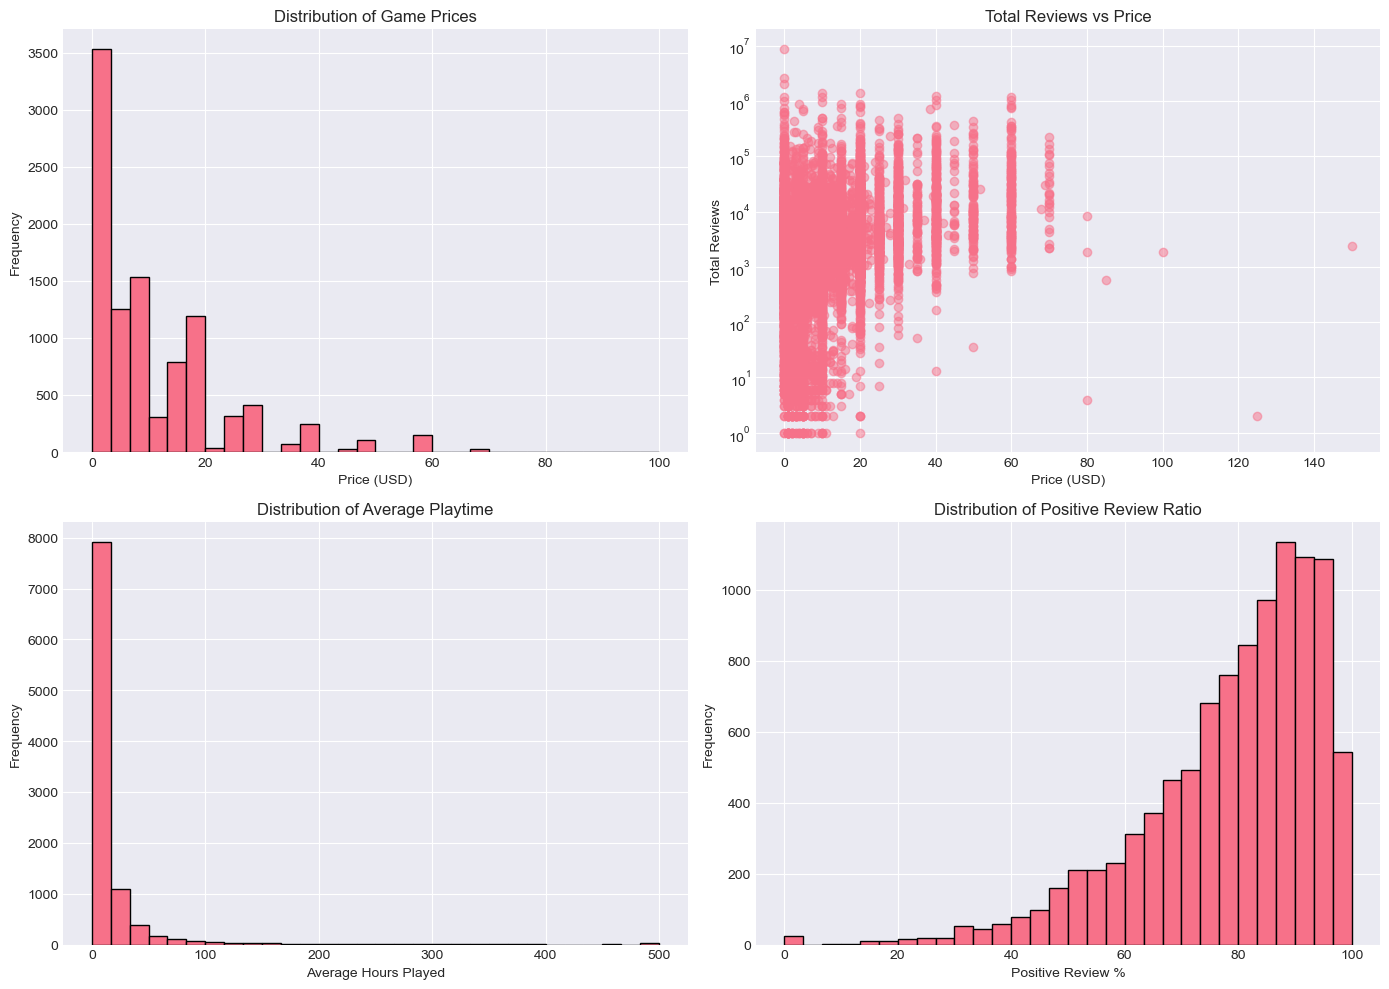

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Price Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price distribution
axes[0,0].hist(df['price_usd'].clip(upper=100), bins=30, edgecolor='black')
axes[0,0].set_title('Distribution of Game Prices')
axes[0,0].set_xlabel('Price (USD)')
axes[0,0].set_ylabel('Frequency')

# Reviews vs Price
axes[0,1].scatter(df['price_usd'], df['total_reviews'], alpha=0.5)
axes[0,1].set_title('Total Reviews vs Price')
axes[0,1].set_xlabel('Price (USD)')
axes[0,1].set_ylabel('Total Reviews')
axes[0,1].set_yscale('log')

# Playtime distribution
axes[1,0].hist(df['avg_hours_forever'].clip(upper=500), bins=30, edgecolor='black')
axes[1,0].set_title('Distribution of Average Playtime')
axes[1,0].set_xlabel('Average Hours Played')
axes[1,0].set_ylabel('Frequency')

# Positive ratio distribution
axes[1,1].hist(df['positive_ratio'].dropna(), bins=30, edgecolor='black')
axes[1,1].set_title('Distribution of Positive Review Ratio')
axes[1,1].set_xlabel('Positive Review %')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
## Correlation Analysis ##

In [48]:
import re

def extract_lower_owner_bound(owners_str):
    if pd.isna(owners_str):
        return None
    # Remove commas and extract the first number in the range
    match = re.match(r'([\d,]+)\s*\.\.', owners_str)
    if match:
        return int(match.group(1).replace(',', ''))
    # Handle single number cases if they exist, or return None/0
    try:
        return int(owners_str.replace(',', ''))
    except ValueError:
        return None

df['owners_lower'] = df['owners'].apply(extract_lower_owner_bound)
print("Created 'owners_lower' column by extracting the lower bound from 'owners' column.")
display(df[['owners', 'owners_lower']].head())

Created 'owners_lower' column by extracting the lower bound from 'owners' column.


,owners,owners_lower
0,"100,000,000 .. 200,000,000",100000000
1,"100,000,000 .. 200,000,000",100000000
2,"100,000,000 .. 200,000,000",100000000
3,"50,000,000 .. 100,000,000",50000000
4,"50,000,000 .. 100,000,000",50000000


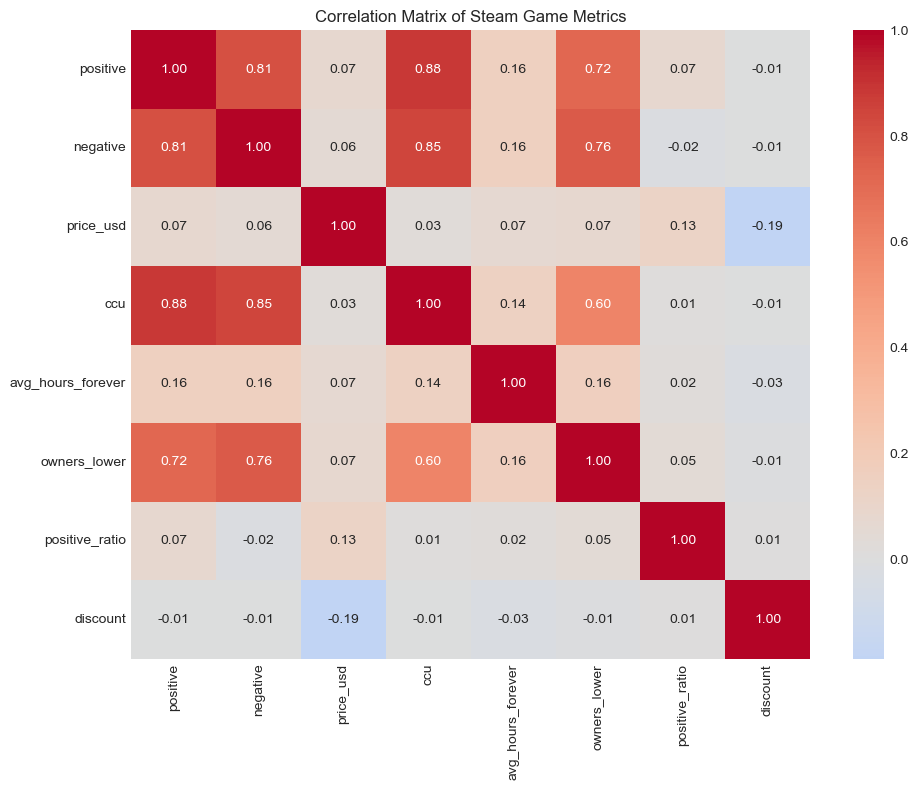

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns for correlation
corr_cols = ['positive', 'negative', 'price_usd', 'ccu', 'avg_hours_forever',
             'owners_lower', 'positive_ratio', 'discount']
corr_matrix = df[corr_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Steam Game Metrics')
plt.tight_layout()
plt.show()

In [ ]:
## Developer/Publisher Analysis ##

In [51]:
# Top developers by number of games
top_devs = df['developer'].value_counts().head(10)
print("Top 10 Developers by Number of Games:")
print(top_devs)

Top 10 Developers by Number of Games:
developer
CAPCOM Co., Ltd.              73
KOEI TECMO GAMES CO., LTD.    40
Square Enix                   40
Valve                         33
Ubisoft Montreal              22
Daedalic Entertainment        20
Codemasters                   18
Milestone S.r.l.              18
id Software                   18
Bohemia Interactive           17
Name: count, dtype: int64


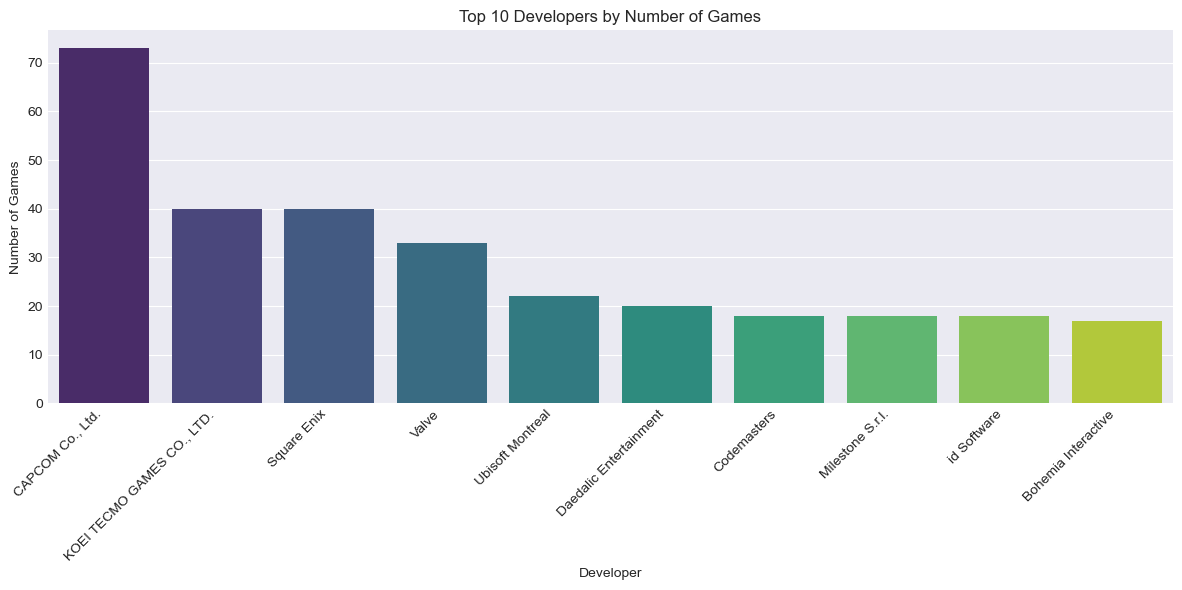

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=top_devs.index, y=top_devs.values, hue=top_devs.index, palette='viridis', legend=False)
plt.title('Top 10 Developers by Number of Games')
plt.xlabel('Developer')
plt.ylabel('Number of Games')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [54]:
# Top publishers by average positive reviews
publisher_stats = df.groupby('publisher').agg({
    'positive': 'mean',
    'name': 'count',
    'total_reviews': 'sum'
}).round(2)
publisher_stats.columns = ['avg_positive', 'game_count', 'total_reviews']
publisher_stats = publisher_stats[publisher_stats['game_count'] >= 5].sort_values('avg_positive', ascending=False).head(10)
print("\nTop Publishers by Average Positive Reviews (min 5 games):")
print(publisher_stats)


Top Publishers by Average Positive Reviews (min 5 games):
                            avg_positive  game_count  total_reviews
publisher                                                          
Valve                          384657.82          33       14138556
KRAFTON, Inc.                  204877.25           8        2705196
CD PROJEKT RED                 195414.00           8        1737642
SCS Software                   170681.83           6        1054687
Larian Studios                 137278.71           7         998274
Rockstar Games                 134226.17          23        3526282
Coffee Stain Publishing        105666.18          11        1221044
Behaviour Interactive Inc.      93023.00           7         829011
Gaijin Network Ltd              85641.86           7         907048
PlayStation Publishing LLC      82811.84          19        1896036


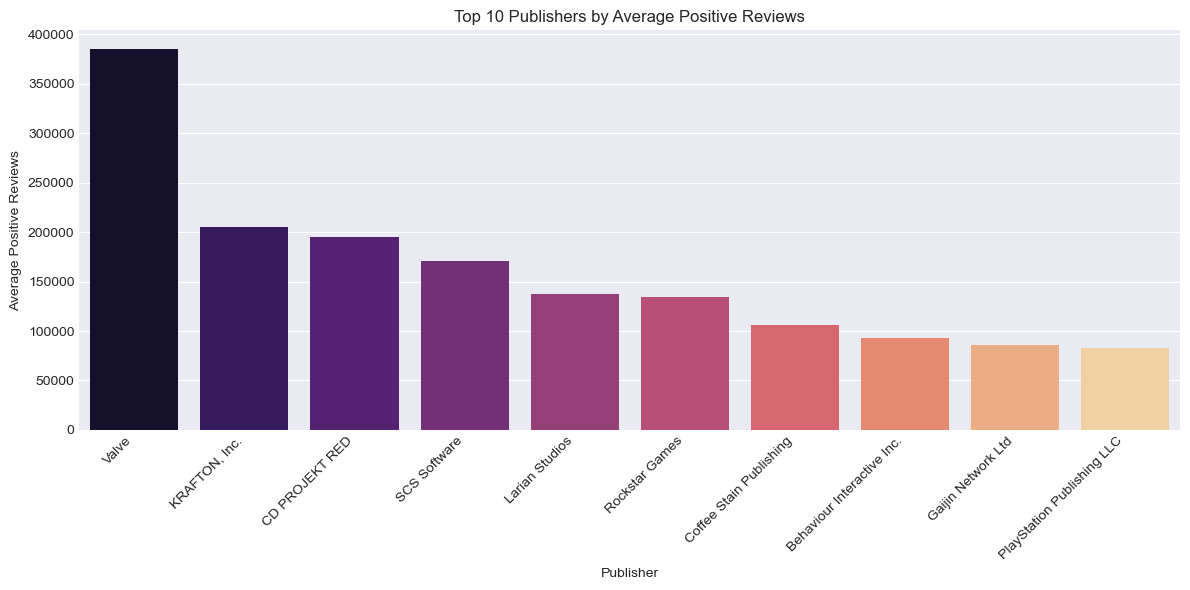

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=publisher_stats.index, y=publisher_stats['avg_positive'], hue=publisher_stats.index, palette='magma', legend=False)
plt.title('Top 10 Publishers by Average Positive Reviews')
plt.xlabel('Publisher')
plt.ylabel('Average Positive Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
## Advanced Analysis: Game Success Metrics ##

In [60]:
# Success score (combination of metrics)
df['success_score'] = (
    df['total_reviews'].rank(pct=True) * 0.3 +
    df['positive_ratio'].rank(pct=True) * 0.3 +
    df['avg_hours_forever'].rank(pct=True) * 0.2 +
    df['ccu'].rank(pct=True) * 0.2
)

print("Top 10 Most Successful Games:")
success_games = df.nlargest(10, 'success_score')[['name', 'total_reviews', 'positive_ratio',
                                                   'avg_hours_forever', 'ccu', 'price_usd', 'success_score']]
print(success_games)

Top 10 Most Successful Games:
                              name  total_reviews  positive_ratio  \
194                       RimWorld         210517       97.956935   
28                  Stardew Valley         886195       98.441539   
17                        Terraria        1409473       97.481754   
19                Wallpaper Engine         894458       98.036800   
127  The Binding of Isaac: Rebirth         343420       97.305049   
45          Euro Truck Simulator 2         867404       97.357172   
171              People Playground         281763       98.574334   
63                  Counter-Strike         250245       97.431717   
22                     Garry's Mod        1159707       96.795656   
166                 Slay the Spire         182277       97.790725   

     avg_hours_forever    ccu  price_usd  success_score  
194         248.216667  19211      34.99       0.986900  
28           81.700000  50662      14.99       0.986593  
17          137.583333  24580       

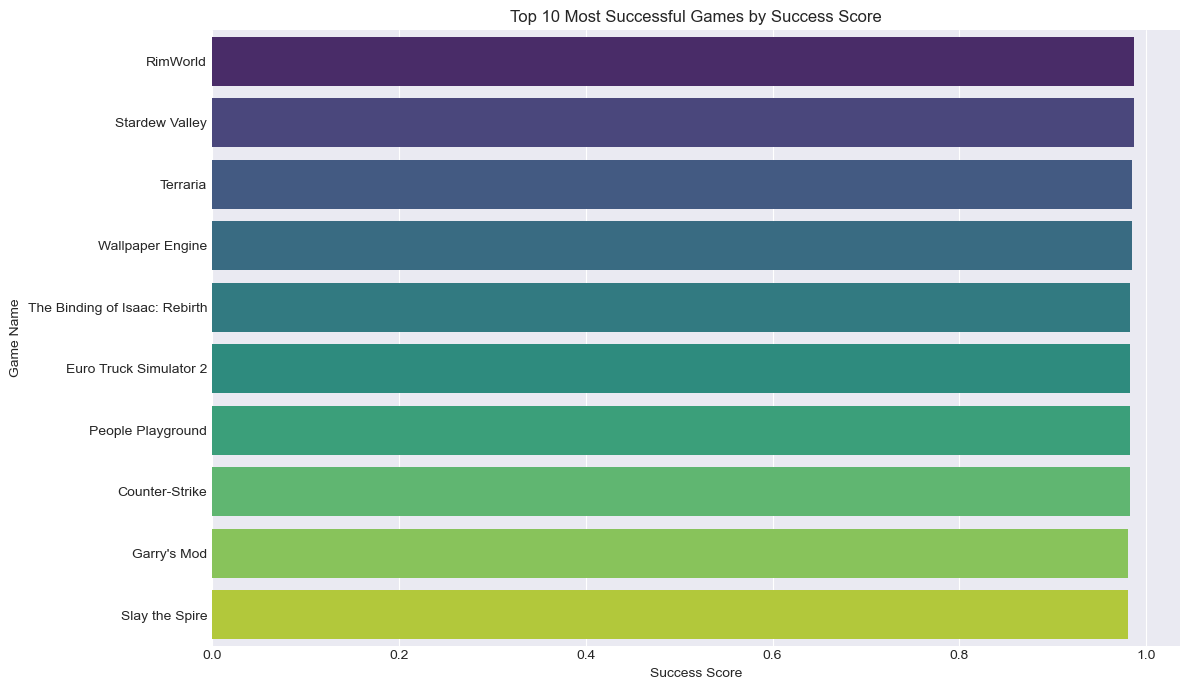

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='success_score', y='name', data=success_games, hue='name', palette='viridis', legend=False)
plt.title('Top 10 Most Successful Games by Success Score')
plt.xlabel('Success Score')
plt.ylabel('Game Name')
plt.tight_layout()
plt.show()

In [62]:
# Free vs Paid games comparison
free_games = df[df['price'] == 0]
paid_games = df[df['price'] > 0]

comparison = pd.DataFrame({
    'Metric': ['Count', 'Avg Reviews', 'Avg Playtime (hours)', 'Avg Positive %'],
    'Free Games': [
        len(free_games),
        free_games['total_reviews'].mean(),
        free_games['avg_hours_forever'].mean(),
        free_games['positive_ratio'].mean()
    ],
    'Paid Games': [
        len(paid_games),
        paid_games['total_reviews'].mean(),
        paid_games['avg_hours_forever'].mean(),
        paid_games['positive_ratio'].mean()
    ]
})
print("\nFree vs Paid Games Comparison:")
print(comparison.round(2))


Free vs Paid Games Comparison:
                 Metric  Free Games  Paid Games
0                 Count     2065.00     7935.00
1           Avg Reviews    17204.30    13279.68
2  Avg Playtime (hours)       22.87       15.55
3        Avg Positive %       74.70       79.95


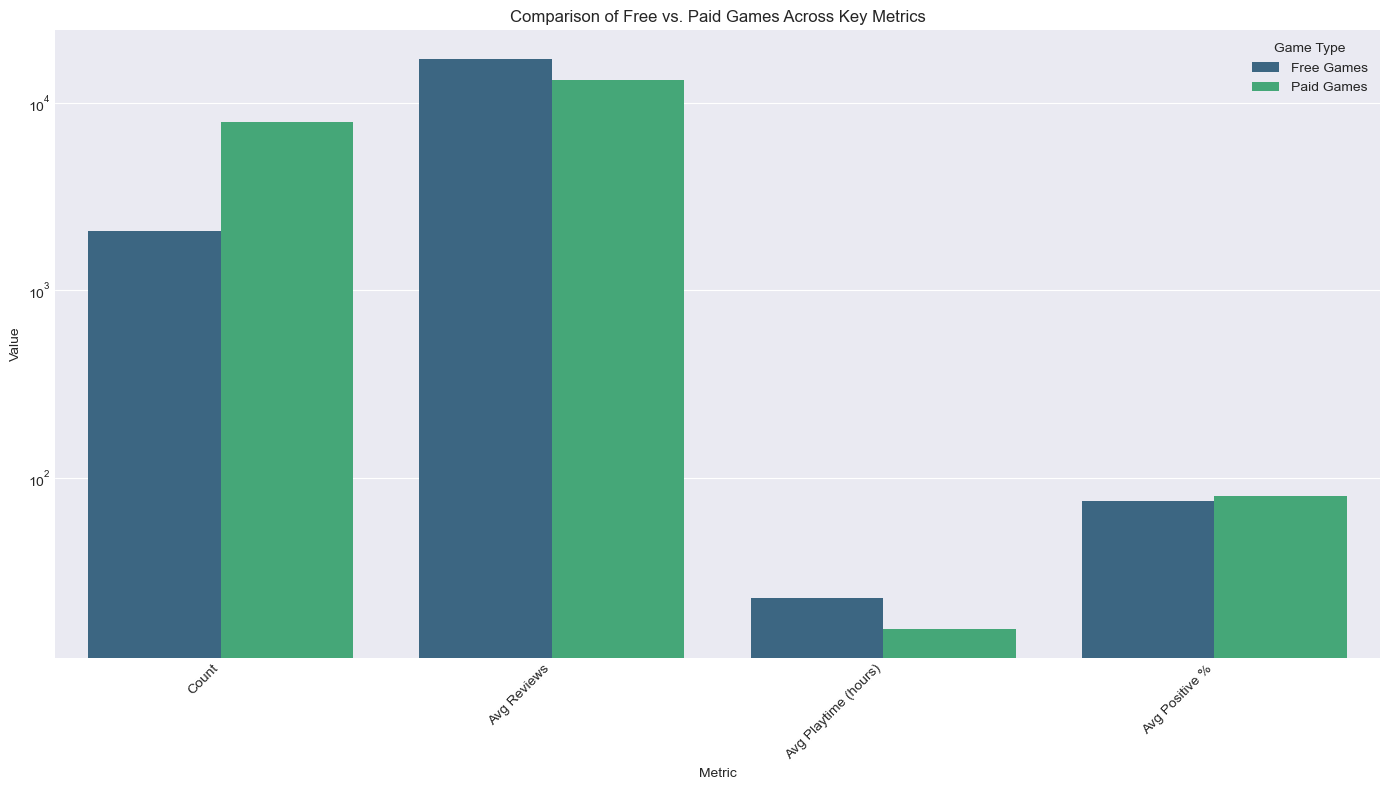

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the comparison DataFrame for easier plotting
comparison_melted = comparison.melt(id_vars='Metric', var_name='Game Type', value_name='Value')

plt.figure(figsize=(14, 8))
sns.barplot(x='Metric', y='Value', hue='Game Type', data=comparison_melted, palette='viridis')
plt.title('Comparison of Free vs. Paid Games Across Key Metrics')
plt.xlabel('Metric')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.yscale('log') # Use a log scale for better visualization of varying magnitudes
plt.tight_layout()
plt.show()